# GENIE mixed-provenance summary (sel_mup CCQE/Ar23p + unfolding-era rest)

Fractional uncertainty summary plots for **integrated** and TKI variables (`tki-del_Tp`, `tki-del_alpha`, `tki-del_phi`), for both **rate** and **xsec**.

**Sources**
- **CCQE, Ar23p** → Aug24 `sel_mup` cov disks (`syst_disk_sel_mup_Aug24_*`)
- **MEC, RES, nonRES, DIS, Other** → unfolding-era `systematics-final/genie-*` NPZs

Mode totals are independent sums of per-mode `genie` / `genie_rate` `cov_frac` blocks.


In [20]:
import os
import pickle
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")
sys.path.insert(0, str(REPO))

from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.final_selected_evt_vars import (
    CORE_SELECTED_EVT_VARIABLE_CONFIGS,
)

SEL_MUP_BASE = Path("/exp/sbnd/data/users/munjung/xsec/numucc_1p0pi")
FINAL_BASE = Path("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final")
OUT_DIR = Path(PLOTS_BASE) / "genie_syst_mixed_sel_mup_CCQE_Ar23p_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARS = ["integrated", "tki-del_Tp", "tki-del_alpha", "tki-del_phi"]
COV_TYPES = ["rate", "xsec"]

# (mode, provenance, path)
GROUP_SOURCES = [
    ("CCQE", "sel_mup", SEL_MUP_BASE / "syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_dict.pkl"),
    ("MEC", "unfolding-era", FINAL_BASE / "genie-MEC/genie-MEC_syst_dict.npz"),
    ("RES", "unfolding-era", FINAL_BASE / "genie-RES/genie-RES_syst_dict.npz"),
    ("nonRES", "unfolding-era", FINAL_BASE / "genie-nonRES/genie-nonRES_syst_dict.npz"),
    ("DIS", "unfolding-era", FINAL_BASE / "genie-DIS/genie-DIS_syst_dict.npz"),
    ("Other", "unfolding-era", FINAL_BASE / "genie-Other/genie-Other_syst_dict.npz"),
    ("Ar23p", "sel_mup", SEL_MUP_BASE / "syst_disk_sel_mup_Aug24_Ar23p/GENIE/cov_mat_dict.pkl"),
]

MODE_COLORS = {
    "CCQE": "#1f77b4",
    "MEC": "#ff7f0e",
    "RES": "#2ca02c",
    "nonRES": "#17becf",
    "DIS": "#d62728",
    "Other": "#9467bd",
    "Ar23p": "#8c564b",
}

SRC_NOTE = (
    "CCQE+Ar23p: sel_mup Aug24; "
    "MEC/RES/nonRES/DIS/Other: systematics-final (unfolding-era)"
)

print("OUT_DIR =", OUT_DIR)
for name, tag, path in GROUP_SOURCES:
    print(f"  {name:7s} [{tag:13s}] exists={path.is_file()}  {path}")


OUT_DIR = /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary
  CCQE    [sel_mup      ] exists=True  /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_dict.pkl
  MEC     [unfolding-era] exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-MEC/genie-MEC_syst_dict.npz
  RES     [unfolding-era] exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-RES/genie-RES_syst_dict.npz
  nonRES  [unfolding-era] exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-nonRES/genie-nonRES_syst_dict.npz
  DIS     [unfolding-era] exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-DIS/genie-DIS_syst_dict.npz
  Other   [unfolding-era] exists=True  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-Other/genie-Other_syst_dict.npz
  Ar23p   [sel_mup      ] exists=True  /exp/sbnd/data/users/m

## Helpers


In [21]:
_STRIP_PREFIXES = (
    "GENIEReWeight_SBN_v1_multisim_",
    "GENIEReWeight_SBN_v1_multisigma_",
    "GENIEReWeight_SBN_v1_",
    "GENIEReWeight_",
    "CCQETemplateReweight_SBN_v3_",
    "CCQETemplateReweight_SBNNuSyst_",
    "CCQETemplateReweight_",
    "QEInterference_",
    "ZExpPCAWeighter_SBN_v3_",
    "ZExpPCAWeighter_SBNNuSyst_",
    "ZExpPCAWeighter_",
    "CCQEXSecCorr_SBN_v3_",
)


def frac_unc_pct(cov_frac) -> np.ndarray:
    c = np.asarray(cov_frac, dtype=np.float64)
    return 100.0 * np.sqrt(np.maximum(np.diag(c), 0.0))


def short_label(knob: str) -> str:
    kn = str(knob)
    for p in _STRIP_PREFIXES:
        if kn.startswith(p):
            kn = kn[len(p) :]
            break
    for tok in ("_multisim", "_multisigma", "_SBN_v1", "_SBN_v3", "_SBNNuSyst"):
        kn = kn.replace(tok, "")
    while "__" in kn:
        kn = kn.replace("__", "_")
    return kn.strip("_").replace("_", " ")


def group_key(knob: str) -> str:
    kn = str(knob)
    if "MvA" in kn and re.search(r"_b\d+$", kn):
        return "MvA"
    if "ZExp" in kn and re.search(r"_b\d+$", kn):
        return "ZExp"
    m = re.search(r"_dial_\d+$", kn)
    if m:
        return short_label(kn[: m.start()])
    m = re.search(r"_q0bin\d+$", kn)
    if m:
        prefix = kn[: m.start()]
        if "Martini" in prefix:
            return "MEC Martini"
        if "Valenica" in prefix or "Valencia" in prefix:
            return "MEC Valencia"
        return short_label(prefix)
    return short_label(kn)


def npz_to_cov_mat_dict(path: Path) -> dict:
    """genie-* NPZ → {var: {knob[,_rate]: cov_frac, genie[,_rate]: sum}}."""
    z = np.load(path, allow_pickle=True)
    out = {}
    for slug in z.files:
        cell = z[slug].item()
        if not isinstance(cell, dict):
            continue
        row = {}
        tot_x = tot_r = None
        for kn, pack in cell.items():
            if not isinstance(pack, dict):
                continue
            for kind, suffix in (("xsec", ""), ("rate", "_rate")):
                if kind not in pack:
                    continue
                sub = pack[kind]
                cf = np.asarray(
                    sub["cov_frac"] if isinstance(sub, dict) else sub,
                    dtype=np.float64,
                )
                row[kn + suffix] = cf
                if kind == "xsec":
                    tot_x = cf.copy() if tot_x is None else tot_x + cf
                else:
                    tot_r = cf.copy() if tot_r is None else tot_r + cf
        if tot_x is not None:
            row["genie"] = tot_x
        if tot_r is not None:
            row["genie_rate"] = tot_r
        out[slug] = row
    return out


def load_groups():
    out, provenance = {}, {}
    for name, tag, path in GROUP_SOURCES:
        if not path.is_file():
            raise FileNotFoundError(path)
        if path.suffix == ".pkl":
            with open(path, "rb") as f:
                out[name] = pickle.load(f)
        elif path.suffix == ".npz":
            out[name] = npz_to_cov_mat_dict(path)
        else:
            raise ValueError(f"unsupported source: {path}")
        provenance[name] = tag
        print(f"loaded {name} [{tag}]: {path}")
    return out, provenance


def collect_knob_mats(groups, slug: str, kind: str):
    parts, mode_totals = {}, {}
    for mode, cov in groups.items():
        if slug not in cov:
            print(f"  warn: {mode} missing {slug}")
            continue
        row = cov[slug]
        tot_key = "genie_rate" if kind == "rate" else "genie"
        if tot_key in row:
            mode_totals[mode] = np.asarray(row[tot_key], dtype=np.float64)
        for key, mat in row.items():
            if key in ("genie", "genie_rate", "genie_ar23", "genie_ar23_rate"):
                continue
            if kind == "rate":
                if not key.endswith("_rate"):
                    continue
                knob = key[: -len("_rate")]
            else:
                if key.endswith("_rate"):
                    continue
                knob = key
            gk = f"{mode}/{group_key(knob)}"
            arr = np.asarray(mat, dtype=np.float64)
            parts[gk] = arr.copy() if gk not in parts else parts[gk] + arr
    return parts, mode_totals


def centers_edges(slug: str, nbin: int, vc_by: dict):
    vc = vc_by.get(slug)
    if vc is not None and len(getattr(vc, "bin_centers", [])) == nbin:
        xlab = vc.var_labels[1] if vc.var_labels else slug
        centers = np.asarray(vc.bin_centers, float)
        edges = None
        bins = getattr(vc, "bins", None)
        if bins is not None and len(bins) == nbin + 1:
            edges = np.asarray(bins, float)
        return centers, edges, xlab
    return np.arange(nbin, dtype=float), None, slug


def plot_mode_totals(ax, slug, mode_totals, vc_by, kind, title):
    if not mode_totals:
        ax.set_title(title + " (empty)")
        return
    ref = next(iter(mode_totals.values()))
    nbin = np.asarray(ref).shape[0]
    centers, edges, xlab = centers_edges(slug, nbin, vc_by)
    bins = edges if edges is not None else np.arange(nbin + 1) - 0.5
    grand = None
    for mode, mat in mode_totals.items():
        arr = np.asarray(mat, dtype=np.float64)
        grand = arr.copy() if grand is None else grand + arr
        w = frac_unc_pct(arr)
        if slug == "integrated":
            w = np.full_like(w, float(w[0]))
        ax.hist(
            centers, bins=bins, weights=w, histtype="step", linewidth=1.8,
            color=MODE_COLORS.get(mode, "gray"), label=mode,
        )
    if grand is not None:
        wtot = frac_unc_pct(grand)
        if slug == "integrated":
            wtot = np.full_like(wtot, float(wtot[0]))
        ax.hist(
            centers, bins=bins, weights=wtot, histtype="step",
            linewidth=2.6, color="k", label="Total",
        )
    ax.set_xlabel(xlab)
    ax.set_ylabel(f"frac. unc. on {kind} [%]")
    ax.set_title(title)
    yhi = 0.0
    for mat in mode_totals.values():
        yhi = max(yhi, float(np.max(frac_unc_pct(mat))))
    if grand is not None:
        yhi = max(yhi, float(np.max(frac_unc_pct(grand))))
    ax.set_ylim(0.0, yhi * 1.3 if yhi > 0.0 else 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2, loc="best")


def plot_grouped_breakdown(ax, slug, parts, total_cov, vc_by, kind, title):
    if not parts and total_cov is None:
        ax.set_title(title + " (empty)")
        return
    ref = total_cov if total_cov is not None else next(iter(parts.values()))
    nbin = np.asarray(ref).shape[0]
    centers, edges, xlab = centers_edges(slug, nbin, vc_by)
    bins = edges if edges is not None else np.arange(nbin + 1) - 0.5
    scores = {k: float(np.mean(frac_unc_pct(m))) for k, m in parts.items()}
    ordered = sorted(scores, key=scores.get, reverse=True)
    cmap = plt.cm.tab20(np.linspace(0, 1, max(len(ordered), 1)))
    for i, gk in enumerate(ordered):
        w = frac_unc_pct(parts[gk])
        if slug == "integrated":
            w = np.full_like(w, float(w[0]))
        ax.hist(
            centers, bins=bins, weights=w, histtype="step", linewidth=1.2,
            color=cmap[i % len(cmap)],
            label=gk if scores[gk] > 0.05 else None,
        )
    if total_cov is not None:
        wtot = frac_unc_pct(total_cov)
        if slug == "integrated":
            wtot = np.full_like(wtot, float(wtot[0]))
        ax.hist(
            centers, bins=bins, weights=wtot, histtype="step",
            linewidth=2.6, color="k", label="Total",
        )
    ax.set_xlabel(xlab)
    ax.set_ylabel(f"frac. unc. on {kind} [%]")
    ax.set_title(title)
    yhi = 0.0
    for m in parts.values():
        yhi = max(yhi, float(np.max(frac_unc_pct(m))))
    if total_cov is not None:
        yhi = max(yhi, float(np.max(frac_unc_pct(total_cov))))
    ax.set_ylim(0.0, yhi * 1.3 if yhi > 0.0 else 1.0)
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    keep = [(h, lab) for h, lab in zip(handles, labels) if lab == "Total"]
    for h, lab in zip(handles, labels):
        if lab != "Total" and len(keep) < 13:
            keep.append((h, lab))
    if keep:
        ax.legend(
            [h for h, _ in keep], [l for _, l in keep],
            fontsize=7, ncol=2, loc="best", framealpha=0.9,
        )


## Load mixed sources


In [22]:
groups, provenance = load_groups()
vc_by = {vc.var_save_name: vc for vc in CORE_SELECTED_EVT_VARIABLE_CONFIGS}
print("vars available (intersection):")
var_sets = [set(g.keys()) for g in groups.values()]
common = set.intersection(*var_sets) if var_sets else set()
print(" ", sorted(common))


loaded CCQE [sel_mup]: /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_dict.pkl
loaded MEC [unfolding-era]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-MEC/genie-MEC_syst_dict.npz
loaded RES [unfolding-era]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-RES/genie-RES_syst_dict.npz
loaded nonRES [unfolding-era]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-nonRES/genie-nonRES_syst_dict.npz
loaded DIS [unfolding-era]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-DIS/genie-DIS_syst_dict.npz
loaded Other [unfolding-era]: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/genie-Other/genie-Other_syst_dict.npz
loaded Ar23p [sel_mup]: /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_Ar23p/GENIE/cov_mat_dict.pkl
vars available (intersection):
  ['integrated', 'tki-del_Tp', 'tki-del_alpha', 'tki-del_phi']


## Integrated mode totals table


In [23]:
rows = []
for kind in COV_TYPES:
    _, mode_totals = collect_knob_mats(groups, "integrated", kind)
    for mode, mat in mode_totals.items():
        rows.append({
            "kind": kind,
            "mode": mode,
            "provenance": provenance[mode],
            "unc_pct": float(frac_unc_pct(mat)[0]),
        })
    if mode_totals:
        grand = sum(np.asarray(m, dtype=np.float64) for m in mode_totals.values())
        rows.append({
            "kind": kind,
            "mode": "Total",
            "provenance": "mixed",
            "unc_pct": float(frac_unc_pct(grand)[0]),
        })

df_int = pd.DataFrame(rows)
display(df_int.pivot(index="mode", columns="kind", values="unc_pct").reindex(
    [m for m, _, _ in GROUP_SOURCES] + ["Total"]
).round(4))


kind,rate,xsec
mode,,
CCQE,8.1950,1.0388
MEC,7.1573,0.9201
RES,0.9002,0.4581
nonRES,0.1562,0.1508
DIS,0.0007,0.0004
Other,6.9308,0.3314
Ar23p,18.1369,2.3594
Total,22.2756,2.7990


## Mode-total plots (2×2: integrated + TKI)


wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_rate__mode_totals_2x2.png


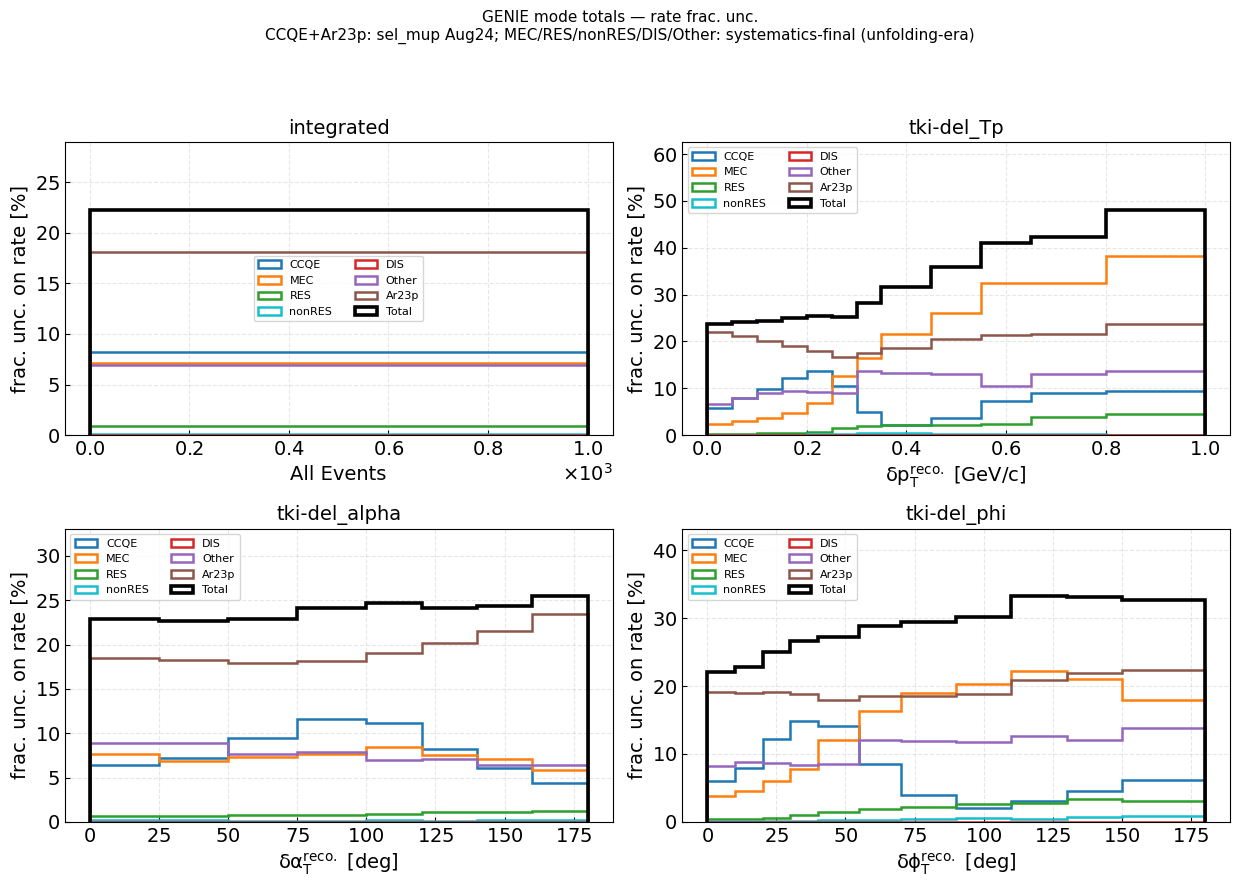

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_xsec__mode_totals_2x2.png


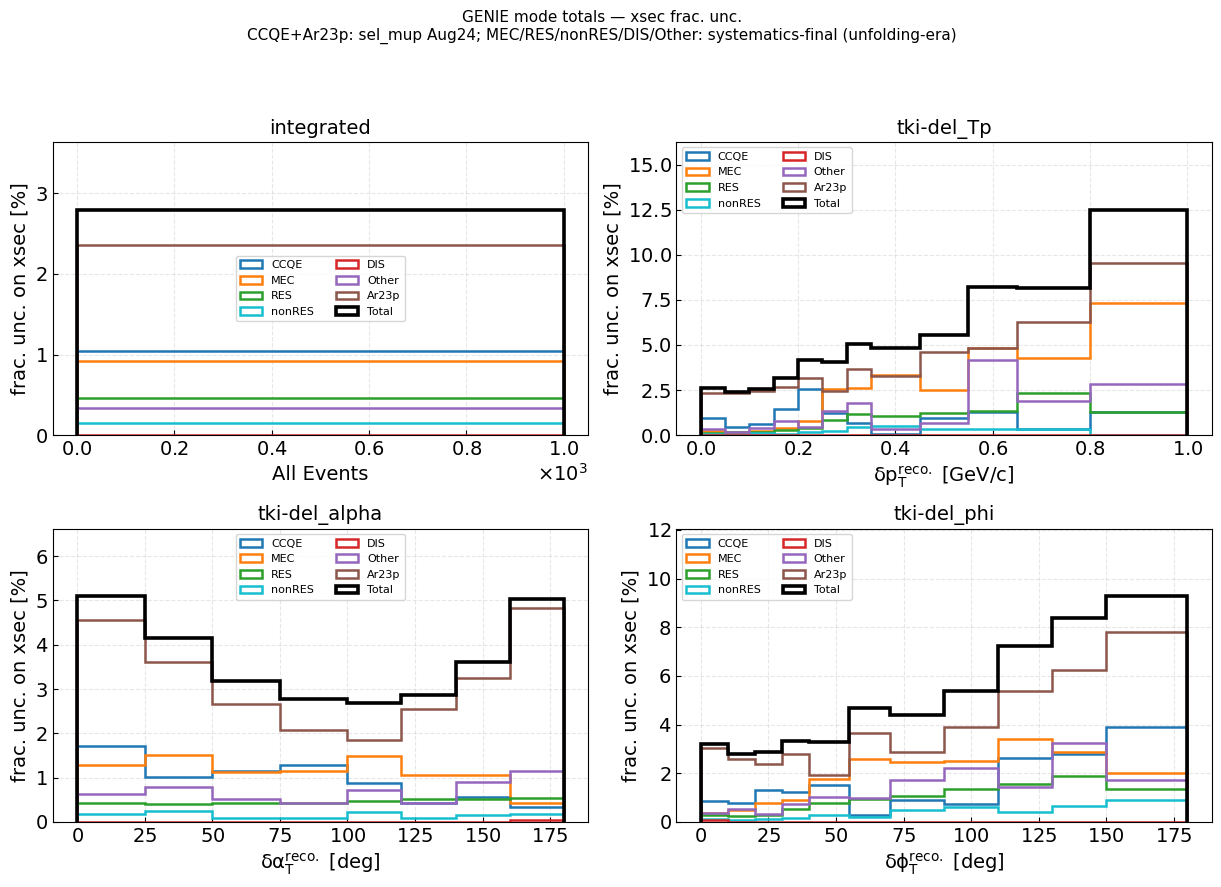

In [24]:
summary_rows = []

for kind in COV_TYPES:
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
    for ax, slug in zip(axes.ravel(), VARS):
        _, mode_totals = collect_knob_mats(groups, slug, kind)
        plot_mode_totals(ax, slug, mode_totals, vc_by, kind, title=slug)
        for mode, mat in mode_totals.items():
            u = frac_unc_pct(mat)
            summary_rows.append({
                "kind": kind,
                "var": slug,
                "source": mode,
                "provenance": provenance.get(mode, ""),
                "mean_unc_pct": float(np.mean(u)),
                "max_unc_pct": float(np.max(u)),
                "integrated_unc_pct": float(u[0]) if slug == "integrated" else float(np.mean(u)),
            })
        if mode_totals:
            grand = sum(np.asarray(m, dtype=np.float64) for m in mode_totals.values())
            u = frac_unc_pct(grand)
            summary_rows.append({
                "kind": kind,
                "var": slug,
                "source": "Total",
                "provenance": "mixed",
                "mean_unc_pct": float(np.mean(u)),
                "max_unc_pct": float(np.max(u)),
                "integrated_unc_pct": float(u[0]) if slug == "integrated" else float(np.mean(u)),
            })
    fig.suptitle(f"GENIE mode totals — {kind} frac. unc.\n{SRC_NOTE}", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    out = OUT_DIR / f"genie_{kind}__mode_totals_2x2.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print("wrote", out)
    plt.show()


## Grouped knob breakdowns (per variable × rate/xsec)


wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_rate__integrated__knob_groups.png


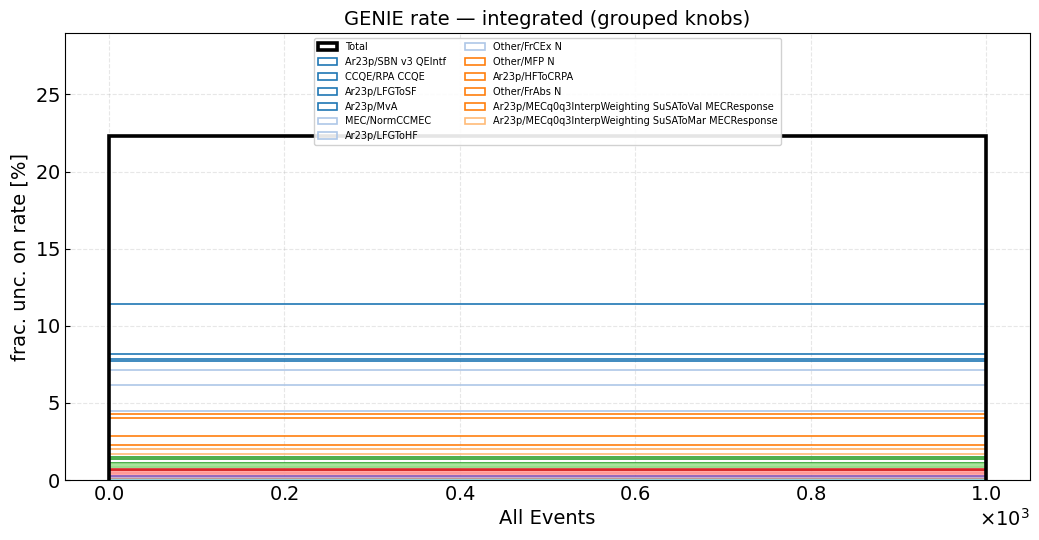

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_rate__tki-del_Tp__knob_groups.png


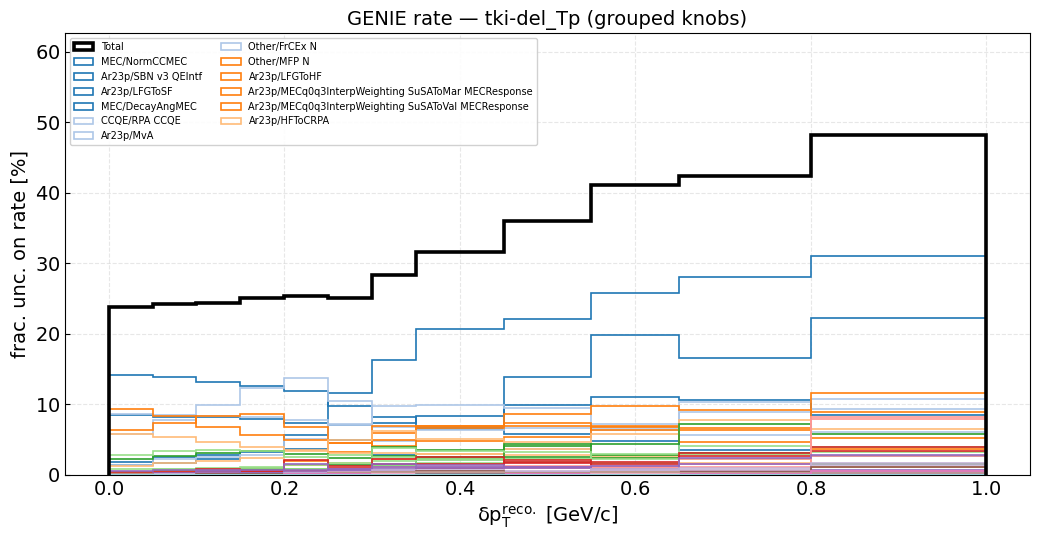

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_rate__tki-del_alpha__knob_groups.png


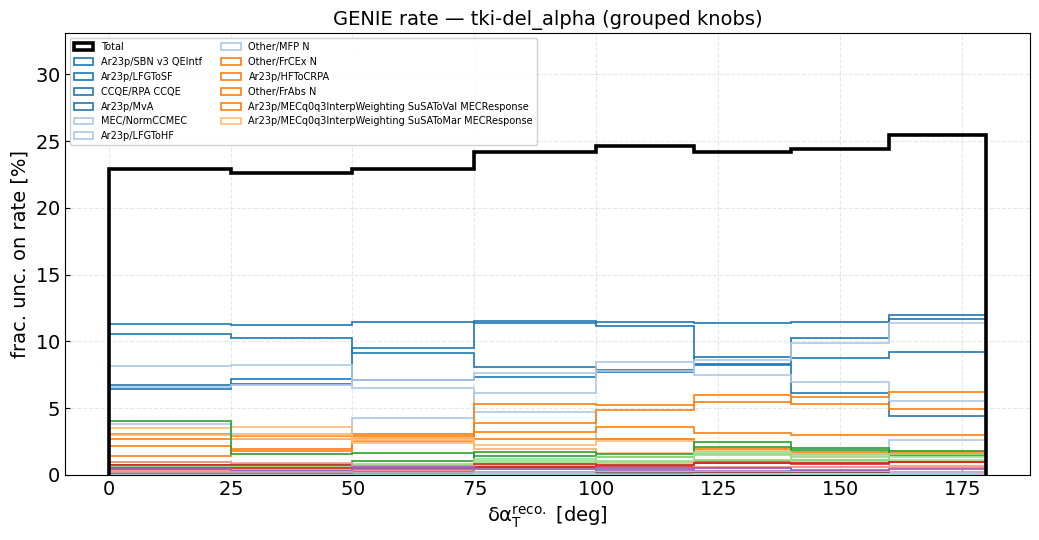

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_rate__tki-del_phi__knob_groups.png


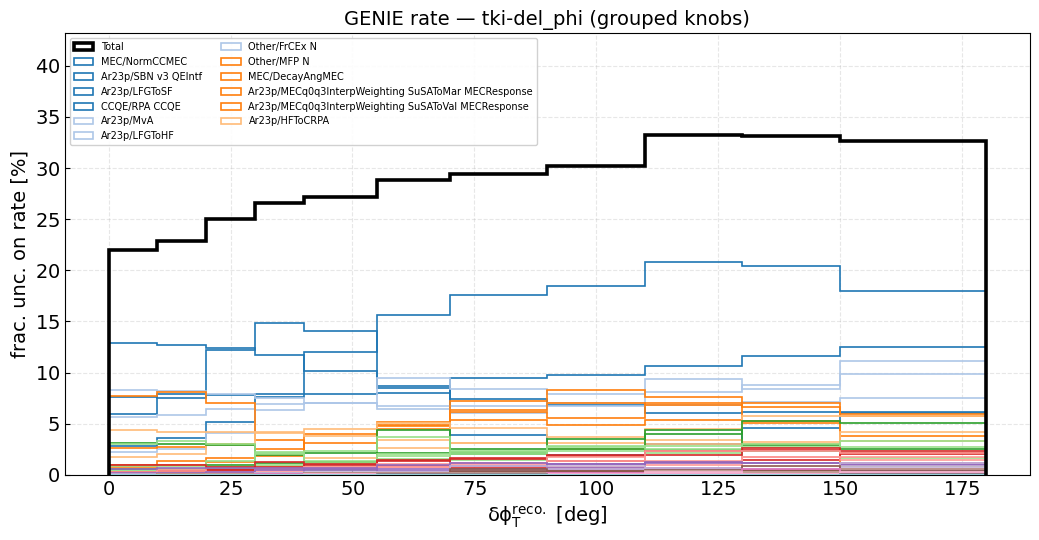

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_xsec__integrated__knob_groups.png


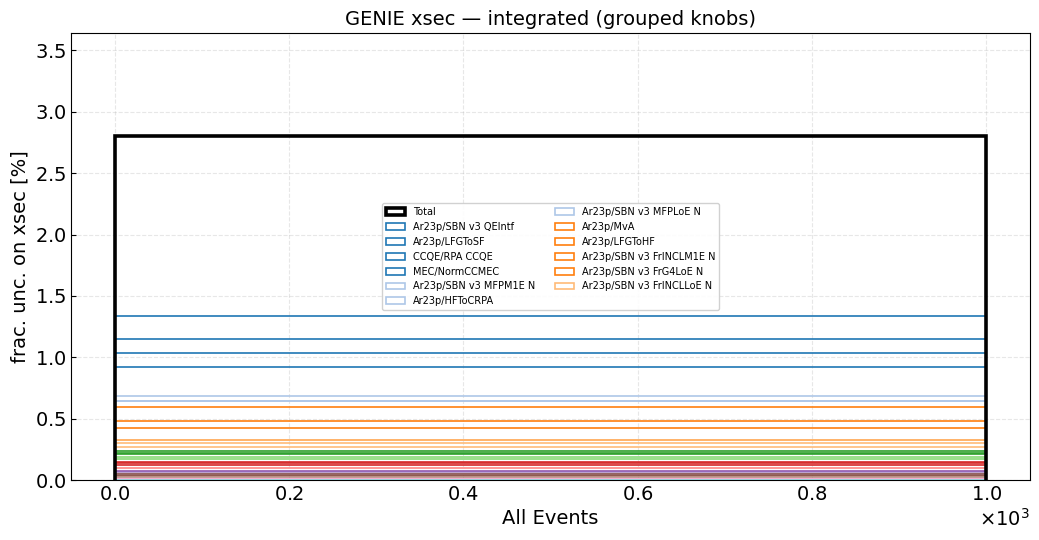

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_xsec__tki-del_Tp__knob_groups.png


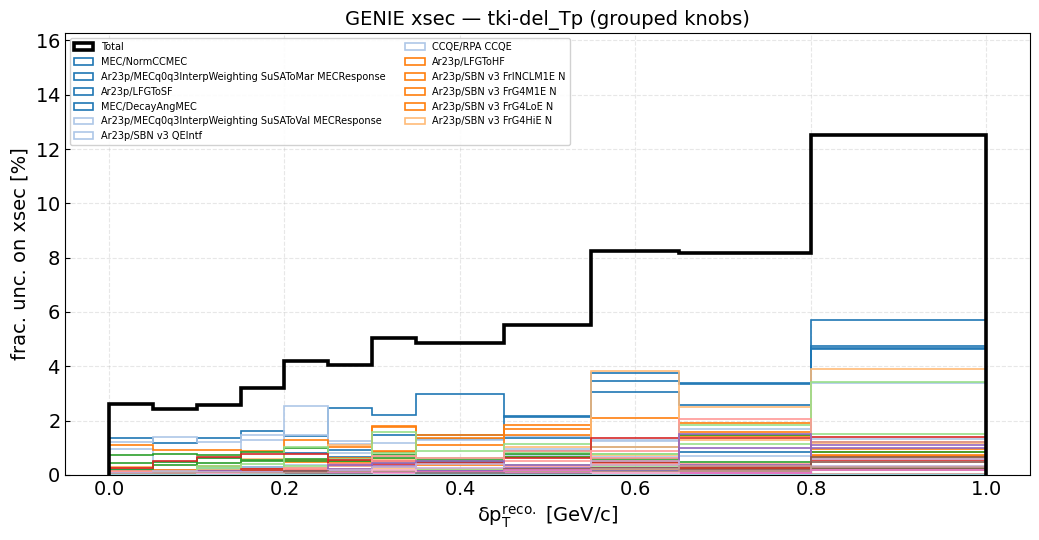

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_xsec__tki-del_alpha__knob_groups.png


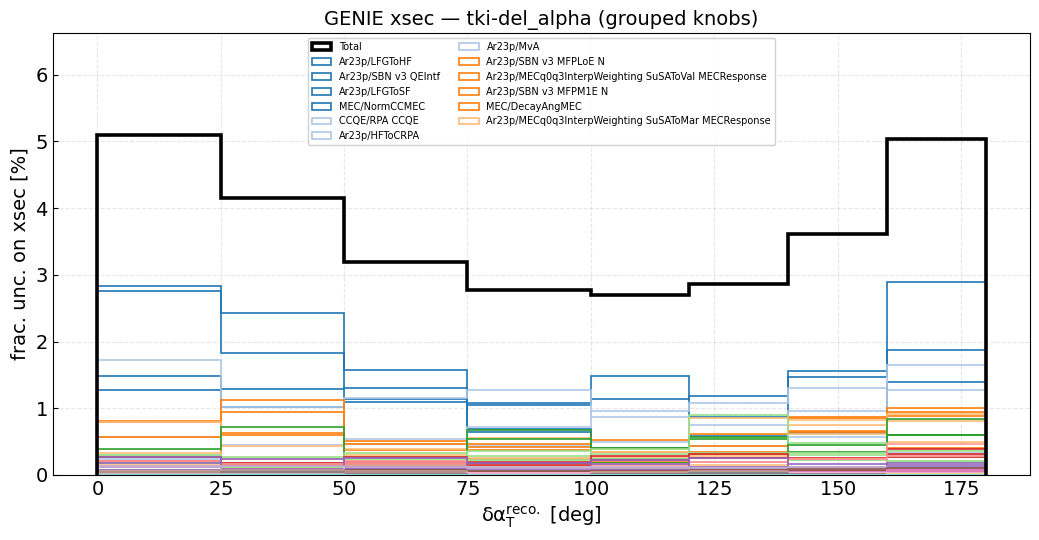

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_xsec__tki-del_phi__knob_groups.png


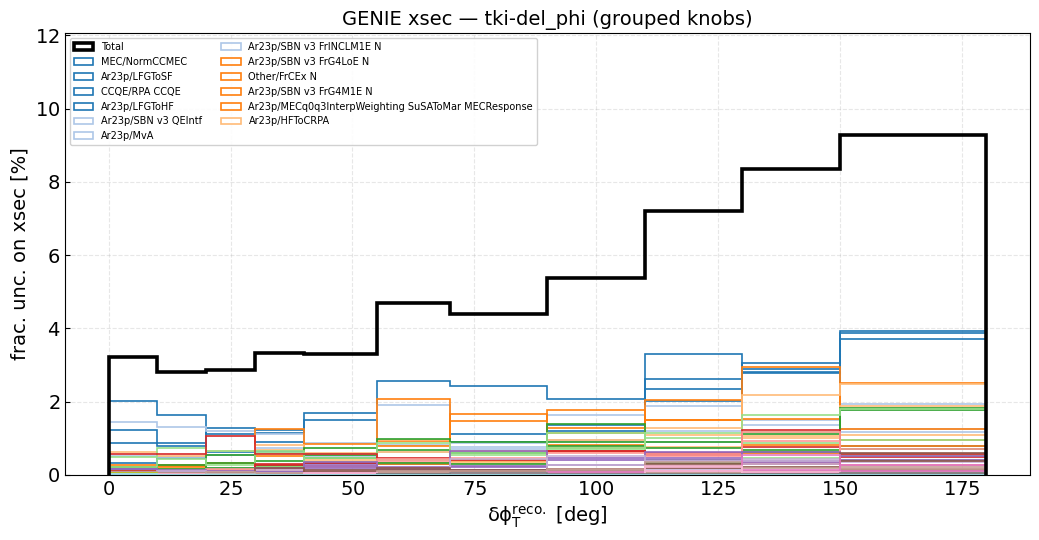

In [25]:
for kind in COV_TYPES:
    for slug in VARS:
        parts, mode_totals = collect_knob_mats(groups, slug, kind)
        grand = None
        if mode_totals:
            grand = sum(np.asarray(m, dtype=np.float64) for m in mode_totals.values())
        fig, ax = plt.subplots(figsize=(10.5, 5.5))
        plot_grouped_breakdown(
            ax, slug, parts, grand, vc_by, kind,
            title=f"GENIE {kind} — {slug} (grouped knobs)",
        )
        fig.tight_layout()
        out = OUT_DIR / f"genie_{kind}__{slug}__knob_groups.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("wrote", out)
        plt.show()


## Save CSV summary


In [26]:
csv_path = OUT_DIR / "genie_mode_totals_summary.csv"
pd.DataFrame(summary_rows).to_csv(csv_path, index=False)
print("wrote", csv_path)
print("OUT_DIR =", OUT_DIR)


wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/genie_mode_totals_summary.csv
OUT_DIR = /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary


## Total uncertainty breakdown (mixed GENIE + unfolding-era categories)

Single-panel category totals in the unfolding-era (`systematics-summary`) style:

- **GENIE** → total from this notebook (sum of mixed-mode `genie` / `genie_rate` `cov_frac`)
- **Flux, Reinteraction, Detector, Cosmics, Beam Exposure, MC Statistics, Number of Targets** → `systematics-final/CategorySummary/category_syst_summary.npz`

GENIE label text uses **GENIE v3.6.0** (not v3.4.0).


In [27]:
from analysis_village.numucc_1p0pi import utils as _numu_utils  # presentation.mplstyle
from analysis_village.numucc_1p0pi.utils import add_approval_text, add_pot_text
from analysis_village.numucc_1p0pi.syst_category_summary import (
    CAT_COSMICS,
    CAT_DETECTOR,
    CAT_FLUX,
    CAT_G4,
    CAT_MCSTAT,
    CAT_NTARGETS,
    CAT_POT,
    category_cov_frac,
    load_category_syst_summary,
    sum_cov_frac_matrices,
)

CATEGORY_SUMMARY_NPZ = (
    FINAL_BASE / "CategorySummary" / "category_syst_summary.npz"
)

# Unfolding-era category keys → plot labels (user-facing names).
UNFOLDING_CAT_LABELS = (
    (CAT_FLUX, "Flux"),
    (CAT_G4, "Reinteraction"),
    (CAT_DETECTOR, "Detector"),
    (CAT_COSMICS, "Cosmics"),
    (CAT_POT, "Beam Exposure"),
    (CAT_MCSTAT, "MC Statistics"),
    (CAT_NTARGETS, "Number of Targets"),
)

CATEGORY_TOTALS_PLOT_ORDER = (
    "Flux",
    "GENIE",
    "Reinteraction",
    "Detector",
    "Beam Exposure",
    "Number of Targets",
    "Cosmics",
    "MC Statistics",
)

BREAKDOWN_FIGSIZE = (8.0, 6.0)
BREAKDOWN_FIG_DPI = 100
BREAKDOWN_SAVE_DPI = int(_numu_utils.dpi)
BREAKDOWN_SUBPLOT_ONPLOT = dict(left=0.11, right=0.99, top=0.94, bottom=0.11)
APPROVAL_TEXT = ""  # off
POT_TEXT = r"8.8 $\times 10^{19}$ POT"
GENIE_VERSION_TEXT = r"GENIE v3.6.0 AR23_00i_00_000"


def _colors_from_cmap(name: str):
    cmap = plt.get_cmap(name)
    n = int(getattr(cmap, "N", 10))
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


_STEP_COLOR_POOL = _colors_from_cmap("tab10") + _colors_from_cmap("Set2")


def _uncertainty_step_colors(n: int):
    if n <= 0:
        return []
    if n <= len(_STEP_COLOR_POOL):
        return _STEP_COLOR_POOL[:n]
    out = list(_STEP_COLOR_POOL)
    k = 0
    while len(out) < n:
        out.append(_STEP_COLOR_POOL[k % len(_STEP_COLOR_POOL)])
        k += 1
    return out[:n]


def _lock_breakdown_figure_size(fig):
    fig.set_size_inches(BREAKDOWN_FIGSIZE, forward=False)
    fig.set_dpi(BREAKDOWN_FIG_DPI)


def _reserve_axes_space_for_top_legend(ax, leg):
    fig = ax.get_figure()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    leg_bbox = leg.get_window_extent(renderer).transformed(ax.transAxes.inverted())
    top_need = float(leg_bbox.y1) + 0.02
    if top_need > 1.0:
        # Legend already outside; nothing to do.
        return


def add_genie_version_text_v360(textloc_x, textloc_y, textloc_ha):
    ax = plt.gcf().axes[0]
    ax.text(
        textloc_x,
        textloc_y,
        GENIE_VERSION_TEXT,
        transform=ax.transAxes,
        ha=textloc_ha,
        va="top",
        fontsize=12,
        color="gray",
    )


def _add_top_center_legend(ax, handles, labels, ncol, fontsize):
    ncol = max(1, min(ncol, len(labels)))
    leg = ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=ncol,
        fontsize=fontsize,
        frameon=True,
        borderaxespad=0.35,
    )
    _reserve_axes_space_for_top_legend(ax, leg)
    fig = ax.get_figure()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    leg_bbox = leg.get_window_extent(renderer).transformed(ax.transAxes.inverted())
    x = 0.63 * (float(leg_bbox.x0) + float(leg_bbox.x1))
    y = float(leg_bbox.y0) + 0.035
    add_genie_version_text_v360(x, y, "center")
    if ax.texts:
        ax.texts[-1].set_zorder(leg.get_zorder() + 1)
    return leg


def style_uncertainty_axis(ax, var_config, pct_series_list, legend_ncol=3, legend_fontsize=16):
    flat = [
        np.asarray(s, dtype=np.float64).ravel()
        for s in pct_series_list
        if s is not None and len(s)
    ]
    # Headroom so the top-center legend does not overlap curves.
    ymax = max(
        (float(np.nanmax(np.where(np.isfinite(x), x, 0.0))) for x in flat),
        default=0.0,
    )
    ax.set_ylim(0.0, ymax * 1.3 if ymax > 0.0 else 1.0)
    ax.set_xlim(var_config.bins[0], var_config.bins[-1])
    xlab = (
        var_config.var_labels[1]
        if getattr(var_config, "var_labels", None)
        else var_config.var_save_name
    )
    ax.set_xlabel(xlab, fontsize=22)
    ax.set_ylabel("Uncertainty [%]", fontsize=22)
    ax.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
    ax.minorticks_on()
    if getattr(var_config, "var_save_name", None) == "integrated":
        ax.set_xticks([])
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    fig = ax.get_figure()
    handles, labels = ax.get_legend_handles_labels()
    fig.subplots_adjust(**BREAKDOWN_SUBPLOT_ONPLOT)
    if labels:
        _add_top_center_legend(ax, handles, labels, legend_ncol, legend_fontsize)

    add_approval_text(APPROVAL_TEXT, 0.01, 1.07, "left")
    add_pot_text(POT_TEXT, 0.99, 1.06, "right", fontsize=16)
    _lock_breakdown_figure_size(fig)


def mixed_genie_total_cov(groups, slug: str, kind: str):
    _, mode_totals = collect_knob_mats(groups, slug, kind)
    if not mode_totals:
        return None
    return sum(np.asarray(m, dtype=np.float64) for m in mode_totals.values())


def build_category_covs_for_plot(summary, groups, slug: str, kind: str):
    """Return Ordered label→cov_frac with mixed GENIE + unfolding-era cats."""
    by_label = {}
    for key, lab in UNFOLDING_CAT_LABELS:
        try:
            by_label[lab] = category_cov_frac(summary, slug, key)
        except KeyError:
            print(f"  warn: missing category {key!r} for {slug}")
    genie_cf = mixed_genie_total_cov(groups, slug, kind)
    if genie_cf is not None:
        by_label["GENIE"] = np.asarray(genie_cf, dtype=np.float64)
    else:
        print(f"  warn: no mixed GENIE total for {slug} / {kind}")
    return by_label


def data_stat_frac_pct(data_evt_df, var_config, scale=1.0):
    """Per-bin data Poisson fractional uncertainty [%]."""
    col = var_config.var_evt_reco_col
    n_data, _ = np.histogram(data_evt_df[col], bins=var_config.bins)
    n_data = np.asarray(n_data, dtype=np.float64)
    n_scaled = n_data * scale
    with np.errstate(divide="ignore", invalid="ignore"):
        n_data_err = np.sqrt(np.maximum(n_scaled, 0.0))
        frac = np.where(n_scaled > 0, n_data_err / n_scaled, 0.0)
    w = 100.0 * frac
    n = len(var_config.bin_centers)
    if len(w) != n:
        if len(w) == 1 and n > 1:
            w = np.full(n, float(w[0]))
        elif len(w) > n:
            w = np.asarray(w[:n], dtype=np.float64)
        elif len(w) < n:
            out = np.zeros(n, dtype=np.float64)
            out[: len(w)] = w
            w = out
    if getattr(var_config, "var_save_name", None) == "integrated" and len(w):
        w = np.full(n, float(np.nanmax(w)))
    return w


def plot_category_totals_single_panel(
    ax,
    var_config,
    by_label,
    data_stat_pct=None,
    data_stat_label="Data stat.",
):
    bins = var_config.bins
    bc = var_config.bin_centers
    plot_labels = [lab for lab in CATEGORY_TOTALS_PLOT_ORDER if lab in by_label]
    colors = _uncertainty_step_colors(len(plot_labels))
    pct_list = []
    mats = []
    for lab, color in zip(plot_labels, colors):
        cf = np.asarray(by_label[lab], dtype=np.float64)
        mats.append(cf)
        w = frac_unc_pct(cf)
        if var_config.var_save_name == "integrated":
            w = np.full_like(w, float(w[0]))
        pct_list.append(w)
        ax.hist(
            bc,
            bins=bins,
            weights=w,
            histtype="step",
            linewidth=2,
            color=color,
            label=lab,
        )
    grand_cf = sum_cov_frac_matrices(mats)
    grand = frac_unc_pct(grand_cf)
    if var_config.var_save_name == "integrated":
        grand = np.full_like(grand, float(grand[0]))
    pct_list.append(grand)
    ax.hist(
        bc,
        bins=bins,
        weights=grand,
        histtype="step",
        linewidth=2,
        color="k",
        label="Total syst.",
    )
    if data_stat_pct is not None:
        dsp = np.asarray(data_stat_pct, dtype=np.float64)
        if var_config.var_save_name == "integrated" and len(dsp):
            dsp = np.full_like(dsp, float(np.nanmax(dsp)))
        pct_list.append(dsp)
        ax.hist(
            bc,
            bins=bins,
            weights=dsp,
            histtype="step",
            linewidth=2,
            color="k",
            linestyle=":",
            label=data_stat_label,
        )
    style_uncertainty_axis(ax, var_config, pct_list, legend_fontsize=14)
    out = {lab: float(frac_unc_pct(by_label[lab])[0]) for lab in plot_labels} | {
        "Total syst.": float(grand[0])
    }
    if data_stat_pct is not None:
        out[data_stat_label] = float(np.nanmax(np.asarray(data_stat_pct, dtype=np.float64)))
    return out



print("CATEGORY_SUMMARY_NPZ =", CATEGORY_SUMMARY_NPZ, "exists=", CATEGORY_SUMMARY_NPZ.is_file())
print("GENIE_VERSION_TEXT =", GENIE_VERSION_TEXT)


CATEGORY_SUMMARY_NPZ = /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz exists= True
GENIE_VERSION_TEXT = GENIE v3.6.0 AR23_00i_00_000


In [28]:
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.beam_quality import apply_beam_quality_cuts

# Same data sample as selected_xsec_overlay default (fvfix+chi2fix + beam quality).
# No saved reco-level data-stat arrays found in prior plot outputs.
DFS_ROOT = Path("/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs")
DATA_DIR = DFS_ROOT / "2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real"
DATA_FILENAME_STR = "sel_mup-data-1e20-fvfix-chi2fix-real"
DATA_STAT_SCALE = 1.0

data_dfs = dfs_from_dir(
    search_dir=str(DATA_DIR),
    filename_str=DATA_FILENAME_STR,
    keys2load=["hdr", "evt", "bnbpot", "trigger"],
    n_max_concat=999,
)
data_evt_df, data_hdr_df, bq_summary = apply_beam_quality_cuts(
    data_dfs["evt"],
    data_dfs["hdr"].join(data_dfs["trigger"]),
    data_dfs["bnbpot"],
)
# integrated uses ('mc','iscc') reco col; mark all data events as selected.
data_evt_df[("mc", "iscc")] = 999
print(
    f"Loaded data for Data stat.: {bq_summary.n_evt_good:,}/{bq_summary.n_evt_prefilter:,} "
    f"evt_good from {DATA_DIR}"
)

data_stat_by_var = {
    slug: data_stat_frac_pct(data_evt_df, vc_by[slug], scale=DATA_STAT_SCALE)
    for slug in VARS
    if slug in vc_by
}
for slug, w in data_stat_by_var.items():
    print(f"  data_stat {slug}: {np.asarray(w).round(2)}")

cat_summary = load_category_syst_summary(str(CATEGORY_SUMMARY_NPZ))
print("loaded category summary vars:", sorted(cat_summary["by_var"].keys()))

total_breakdown_rows = []
for kind in COV_TYPES:
    for slug in VARS:
        vc = vc_by.get(slug)
        if vc is None:
            print(f"skip {slug}: no VariableConfig")
            continue
        by_label = build_category_covs_for_plot(cat_summary, groups, slug, kind)
        fig = plt.figure(figsize=BREAKDOWN_FIGSIZE, dpi=BREAKDOWN_FIG_DPI)
        ax = fig.add_subplot(111)
        fig.subplots_adjust(**BREAKDOWN_SUBPLOT_ONPLOT)
        ints = plot_category_totals_single_panel(
            ax,
            vc,
            by_label,
            data_stat_pct=data_stat_by_var.get(slug),
        )
        out = OUT_DIR / f"total_syst_breakdown__{kind}__{slug}.png"
        fig.savefig(out, dpi=BREAKDOWN_SAVE_DPI)
        plt.close(fig)
        print(f"wrote {out}")
        for lab, val in ints.items():
            total_breakdown_rows.append(
                {"kind": kind, "var": slug, "category": lab, "frac_unc_pct": val}
            )

csv_tot = OUT_DIR / "total_syst_breakdown_summary.csv"
pd.DataFrame(total_breakdown_rows).to_csv(csv_tot, index=False)
print("wrote", csv_tot)

# Quick integrated xsec view
df_tot = pd.DataFrame(total_breakdown_rows)
print("\nintegrated / xsec:")
print(
    df_tot[(df_tot["kind"] == "xsec") & (df_tot["var"] == "integrated")]
    .set_index("category")["frac_unc_pct"]
    .round(3)
    .to_string()
)


Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_o

100%|██████████| 100/100 [45:46<00:00, 27.46s/it]   


REMEMBER TO RECALCULATE TKI AND CHECK FV!!


/tmp/ipykernel_3200629/1197002473.py:23: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df[("mc", "iscc")] = 999


Loaded data for Data stat.: 12,802/13,034 evt_good from /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063308__sel_mup-data-1e20-fvfix-chi2fix-real
  data_stat integrated: [0.88]
  data_stat tki-del_Tp: [ 3.7   2.35  2.07  2.12  2.54  3.1   3.56  3.    3.72  5.6   8.48 20.85]
  data_stat tki-del_alpha: [2.71 2.68 2.59 2.34 2.47 2.34 2.41 2.54]
  data_stat tki-del_phi: [1.73 1.93 2.31 2.87 3.   3.65 3.94 4.62 6.01 7.02 6.55]
loaded category summary vars: ['integrated', 'muon-dir_z', 'muon-p', 'proton-dir_z', 'proton-p', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_alpha', 'tki-del_p', 'tki-del_phi']
wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/total_syst_breakdown__rate__integrated.png
wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/total_syst_breakdown__rate__tki-del_Tp.png
wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_s

## Export total syst for unfolding (`category_syst_summary.npz`)

Writes a drop-in `CategorySummary/category_syst_summary.npz` under `OUT_DIR` for
`unfolding-gen1-final.ipynb`:

- Replaces **GENIE** (`genie_xsec` / `genie_rate`) with this notebook’s mixed total
- Keeps Flux / Reinteraction / Detector / Cosmics / Beam Exposure / MC Statistics /
  Number of Targets from the unfolding-era summary
- Rebuilds `total_xsec` and `total_rate`

Also writes slim `total_frac_cov__{rate,xsec}.pkl` maps `{var: cov_frac}` for quick loads.


In [29]:
from copy import deepcopy
from datetime import datetime, timezone
import json

from analysis_village.numucc_1p0pi.syst_category_summary import (
    CAT_GENIE_RATE,
    CAT_GENIE_XSEC,
    SCHEMA,
    TOTAL_RATE,
    TOTAL_XSEC,
    _RATE_TOTAL_CATEGORIES,
    _XSEC_TOTAL_CATEGORIES,
    _category_block,
    category_summary_manifest_path,
)

# Drop-in NPZ layout matching systematics-final/CategorySummary/
CAT_OUT_DIR = OUT_DIR / "CategorySummary"
CAT_OUT_DIR.mkdir(parents=True, exist_ok=True)
MIXED_CATEGORY_SUMMARY_NPZ = CAT_OUT_DIR / "category_syst_summary.npz"


def _rebuild_total_block(categories: dict, keys, var_config) -> dict:
    parts = []
    used = []
    for k in keys:
        blk = categories.get(k)
        if not isinstance(blk, dict) or blk.get("cov_frac") is None:
            continue
        parts.append(np.asarray(blk["cov_frac"], dtype=np.float64))
        used.append(k)
    if not parts:
        return {}
    total = sum_cov_frac_matrices(parts)
    out = _category_block(total, var_config, nominal_mc=None)
    out["category_keys"] = np.array(used, dtype=object)
    return out


def export_mixed_category_syst_summary(
    cat_summary,
    groups,
    out_npz: Path,
    var_configs_by_name: dict,
) -> dict:
    """Clone unfolding-era packs; swap GENIE with mixed totals; rewrite totals."""
    by_var = {}
    replaced = []
    kept_genie = []
    for vsn, pack0 in cat_summary["by_var"].items():
        pack = deepcopy(pack0)
        cats = pack.setdefault("categories", {})
        vc = var_configs_by_name.get(vsn)
        if vc is None:

            class _VC:
                var_save_name = vsn
                bins = pack.get("bins")
                bin_centers = pack.get("bin_centers")

            vc = _VC()

        gx = mixed_genie_total_cov(groups, vsn, "xsec") if vsn in VARS else None
        gr = mixed_genie_total_cov(groups, vsn, "rate") if vsn in VARS else None
        # Only swap GENIE when this notebook has the full mixed-mode set for ``vsn``.
        # Other vars keep unfolding-era GENIE (sel_mup CCQE/Ar23p disks are 4-var only).
        if gx is not None and all(vsn in g for g in groups.values()):
            cats[CAT_GENIE_XSEC] = _category_block(gx, vc, nominal_mc=None)
        else:
            gx = None
        if gr is not None and all(vsn in g for g in groups.values()):
            cats[CAT_GENIE_RATE] = _category_block(gr, vc, nominal_mc=None)
        else:
            gr = None
        if gx is not None or gr is not None:
            replaced.append(vsn)
        else:
            kept_genie.append(vsn)

        rate_blk = _rebuild_total_block(cats, _RATE_TOTAL_CATEGORIES, vc)
        xsec_blk = _rebuild_total_block(cats, _XSEC_TOTAL_CATEGORIES, vc)
        if rate_blk:
            pack[TOTAL_RATE] = rate_blk
        if xsec_blk:
            pack[TOTAL_XSEC] = xsec_blk
        pack["schema"] = SCHEMA
        pack["var_save_name"] = vsn
        by_var[vsn] = pack

    out_npz = Path(out_npz)
    out_npz.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(out_npz, **by_var)

    manifest = {
        "schema": SCHEMA,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "description": (
            "Mixed GENIE (sel_mup CCQE+Ar23p + unfolding-era other GENIE modes) "
            "with unfolding-era non-GENIE categories; totals rebuilt."
        ),
        "source_category_summary": str(CATEGORY_SUMMARY_NPZ),
        "genie_sources": {name: tag for name, tag, _ in GROUP_SOURCES},
        "npz_path": str(out_npz),
        "variables": sorted(by_var.keys()),
        "genie_replaced_vars": replaced,
        "genie_kept_unfolding_era_vars": kept_genie,
        "total_keys": [TOTAL_RATE, TOTAL_XSEC],
        "genie_version_label": GENIE_VERSION_TEXT,
        "usage": {
            "unfolding": (
                "np.load(npz_path, allow_pickle=True); "
                "frac = z[var].item()['total_xsec']['cov_frac']"
            ),
        },
    }
    man_path = Path(category_summary_manifest_path(str(out_npz)))
    man_path.write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


manifest = export_mixed_category_syst_summary(
    cat_summary, groups, MIXED_CATEGORY_SUMMARY_NPZ, vc_by
)
print("wrote", MIXED_CATEGORY_SUMMARY_NPZ)
print("manifest:", category_summary_manifest_path(str(MIXED_CATEGORY_SUMMARY_NPZ)))
print("GENIE replaced for:", manifest["genie_replaced_vars"])
print("GENIE kept unfolding-era for:", manifest["genie_kept_unfolding_era_vars"])

# Slim frac-cov dicts (var → cov_frac) for rate / xsec totals
z_out = np.load(MIXED_CATEGORY_SUMMARY_NPZ, allow_pickle=True)
for kind, total_key in (("rate", TOTAL_RATE), ("xsec", TOTAL_XSEC)):
    frac_map = {}
    for vsn in z_out.files:
        pack = z_out[vsn].item()
        if total_key not in pack:
            continue
        frac_map[vsn] = np.asarray(pack[total_key]["cov_frac"], dtype=np.float64)
    out_pkl = OUT_DIR / f"total_frac_cov__{kind}.pkl"
    with open(out_pkl, "wb") as f:
        pickle.dump(frac_map, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"wrote {out_pkl}  ({len(frac_map)} vars)")

cf = z_out["integrated"].item()[TOTAL_XSEC]["cov_frac"]
print(
    f"integrated total_xsec frac unc = "
    f"{float(100 * np.sqrt(np.maximum(np.diag(cf), 0.0))[0]):.4f}%"
)
print("\nFor unfolding-gen1-final.ipynb set:")
print(f"  CATEGORY_SUMMARY_NPZ = Path({str(MIXED_CATEGORY_SUMMARY_NPZ)!r})")


wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/CategorySummary/category_syst_summary.npz
manifest: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/CategorySummary/category_syst_summary_manifest.json
GENIE replaced for: ['integrated', 'tki-del_alpha', 'tki-del_phi', 'tki-del_Tp']
GENIE kept unfolding-era for: ['muon-p', 'muon-dir_z', 'proton-p', 'proton-dir_z', 'tki-del_p', 'tki-del_Tp_x', 'tki-del_Tp_y']
wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/total_frac_cov__rate.pkl  (11 vars)
wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/total_frac_cov__xsec.pkl  (11 vars)
integrated total_xsec frac unc = 7.9063%

For unfolding-gen1-final.ipynb set:
  CATEGORY_SUMMARY_NPZ = Path('/exp/sbnd/data/users/munjung/plots/numucc1p0pi/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary/CategorySummary/category_syst_sum